In [1]:
import tensorflow as tf

2026-01-07 16:11:57.458782: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767802317.715492      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767802317.783652      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767802318.407093      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767802318.407154      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767802318.407157      55 computation_placer.cc:177] computation placer alr

In [2]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [5]:
path = '/kaggle/input/plantvillage-dataset/color'
image_width = 64
image_height = 64
batch_size = 32

In [29]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  path,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(image_width, image_height),
  batch_size=batch_size)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


In [30]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  path,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(image_height, image_width),
  batch_size=batch_size)

Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [31]:
class_names = train_ds.class_names
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [9]:
num_classes = len(class_names)
print(num_classes)

38


In [10]:
normalization_layer = layers.Rescaling(1./255)

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [12]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization_layer(x)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

In [17]:
model = models.Sequential([
    layers.Input(shape=(64,64, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 122s 89ms/step - accuracy: 0.4230 - loss: 2.1255 - val_accuracy: 0.7139 - val_loss: 0.9403
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 116s 86ms/step - accuracy: 0.7024 - loss: 0.9743 - val_accuracy: 0.7897 - val_loss: 0.6574
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 115s 85ms/step - accuracy: 0.7665 - loss: 0.7508 - val_accuracy: 0.8132 - val_loss: 0.5974
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 116s 85ms/step - accuracy: 0.8017 - loss: 0.6290 - val_accuracy: 0.8171 - val_loss: 0.5811
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 142s 85ms/step - accuracy: 0.8266 - loss: 0.5394 - val_accuracy: 0.8495 - val_loss: 0.4702
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 116s 85ms/step - accuracy: 0.8485 - loss: 0.4700 - val_accuracy: 0.8436 - val_loss: 0.5179
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 116s 85ms/step - accuracy: 0.8629 - loss: 0.4297 - val_accuracy: 0.8637 - val_loss: 0.4521
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 119s 87ms/step - accuracy: 

In [20]:
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

print("Final Training Accuracy:", train_acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

Final Training Accuracy: 0.9000552296638489
Final Validation Accuracy: 0.8227603435516357


In [23]:
loss = history.history['loss']
val_loss = history.history['val_loss']
print("Final Training Loss : " , loss[-1])
print("Final Validation Loss: ", val_loss[-1])

Final Training Loss :  0.2953527271747589
Final Validation Loss:  0.645357608795166


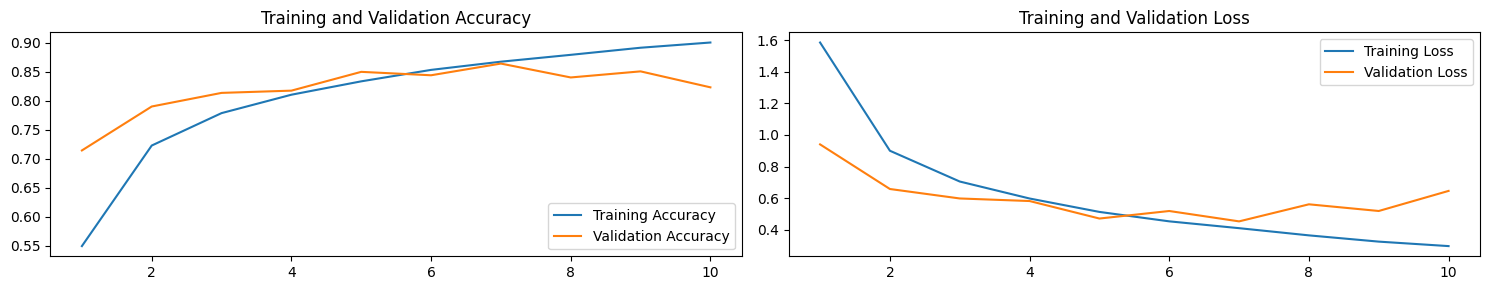

In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(1,11)

plt.figure(figsize=(15, 3))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.tight_layout()
plt.show()

In [25]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch, verbose=0)

    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds,axis=1))

In [32]:
from sklearn.metrics import classification_report 

print(classification_report(y_true, y_pred, target_names = val_ds.class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.58      0.72      0.64       120
                                 Apple___Black_rot       0.58      0.88      0.70       124
                          Apple___Cedar_apple_rust       1.00      0.20      0.33        56
                                   Apple___healthy       0.91      0.74      0.82       348
                               Blueberry___healthy       0.96      0.86      0.91       318
          Cherry_(including_sour)___Powdery_mildew       0.90      0.75      0.82       208
                 Cherry_(including_sour)___healthy       0.86      0.80      0.83       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.66      0.74      0.70       109
                       Corn_(maize)___Common_rust_       0.98      0.98      0.98       238
               Corn_(maize)___Northern_Leaf_Blight       0.87      0.81      0.